

<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## k-Nearest Neighbors Sensitivity to Measurement Noise in Subsurface Production Prediction

#### Haidar Almajed
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Professor, The University of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin


### Executive Summary

Distance-based machine learning methods like k-Nearest Neighbors (k-NN) are widely used in subsurface applications for production forecasting due to their simplicity and interpretability. However, subsurface measurements are inherently noisy due to instrumentation limitations, wellbore conditions, and operational variability. While practitioners often acknowledge measurement uncertainty qualitatively, the quantitative impact of noise on k-NN performance remains poorly characterized. This knowledge gap is critical because choosing an inappropriate algorithm for noisy data can lead to unreliable predictions that mislead reservoir management decisions.

This workflow investigates a fundamental question: **At what noise level does k-NN become unreliable for subsurface production prediction?** Using the bootstrap methodology (Efron and Tibshirani, 1994) with 50 realizations per noise level, I systematically evaluate k-NN performance (Cover and Hart, 1967; Altman, 1992; Pyrcz, 2024b) across six noise intensities (standard deviations from 0 to 1000 MCFPD) on synthetic unconventional reservoir data (unconv_MV_v5.csv; Pyrcz, 2024a). The analysis tracks not only prediction error using RMSE and R² metrics (James et al., 2013) but also the adaptive behavior of optimal hyperparameters as noise increases, providing insights into the fundamental limitations of distance-based methods in noisy environments.

The results reveal important findings about k-NN's noise tolerance: while k-NN maintains good performance up to SD=500 (R²=0.79), performance degrades progressively beyond this point. The model compensates by increasing the number of neighbors from k=3 (clean data) to k=18 (SD=1000), which helps maintain R²=0.50 even at extreme noise levels - demonstrating better resilience than initially hypothesized. At SD=700, RMSE increases from 140 to 701 MCFPD (5× increase) while R² decreases from 0.98 to 0.67. Comparison with Ridge Regression (Hoerl and Kennard, 1970) and Random Forest (Breiman, 2001) at SD=700 shows that ensemble methods provide superior noise resistance, with Random Forest achieving RMSE=527 and R²=0.81 versus k-NN's RMSE=699 and R²=0.67.

These findings have key implications: for subsurface production forecasting, k-NN remains viable up to noise SD≈500 MCFPD (approximately 12% of typical production values). Beyond SD=500, Random Forest should be preferred for its superior noise robustness. The study demonstrates that while k-NN adapts reasonably well to moderate noise through hyperparameter tuning, ensemble methods like Random Forest provide better performance in high-noise environments common to subsurface measurements.

### Load Required Libraries

We import the standard data science stack along with scikit-learn (Pedregosa et al., 2011) for machine learning models and cross-validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)



### Load Data

The workflow uses **unconv_MV_v5.csv**, a synthetic unconventional reservoir dataset representing 200 wells. This dataset was generated using geostatistical simulation (Pyrcz and Deutsch, 2014) and is publicly available for reproducibility (Pyrcz, 2024a).

**Features:**
* **Porosity** - fraction of rock void space, dimensionless (0-1 scale, percentage)
* **Brittleness** - rock's tendency to fracture, dimensionless index (0-100 scale)

**Target Variable:**
* **Production** - initial gas production rate in thousand cubic feet per day (MCFPD)

Two features were chosen to expedite the analysis while maintaining interpretability.

Dataset shape: 200 wells, 2 features

Feature statistics:
              Por     Brittle         Prod
count  200.000000  200.000000   200.000000
mean    14.991150   48.161950  4311.219852
std      2.971176   14.129455   992.038414
min      6.550000   10.940000  2107.139414
25%     12.912500   37.755000  3618.064513
50%     15.070000   49.510000  4284.687348
75%     17.402500   58.262500  5086.089761
max     23.550000   84.330000  6662.622385


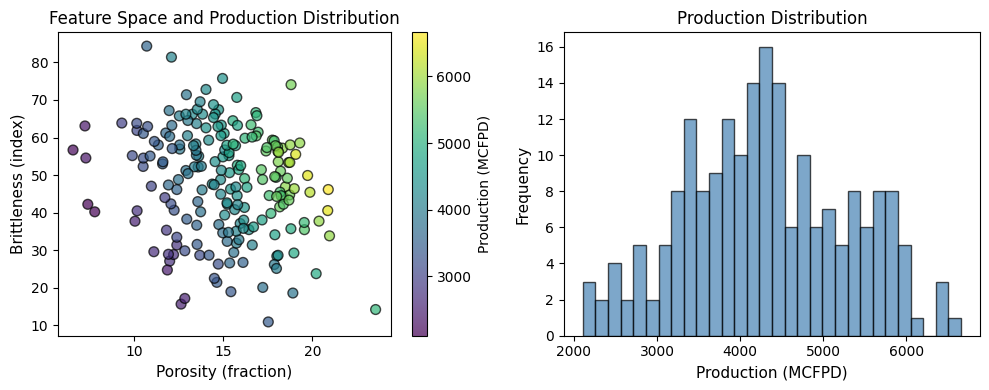

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v5.csv"
data = pd.read_csv(url)

features = ['Por', 'Brittle']
target = 'Prod'

X = data[features].values
y = data[target].values

print(f'Dataset shape: {X.shape[0]} wells, {X.shape[1]} features')
print(f'\nFeature statistics:')
print(data[features + [target]].describe())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50,
            edgecolors='black', alpha=0.7)
plt.xlabel('Porosity (fraction)', fontsize=11)
plt.ylabel('Brittleness (index)', fontsize=11)
plt.colorbar(label='Production (MCFPD)')
plt.title('Feature Space and Production Distribution', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Production (MCFPD)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Production Distribution', fontsize=12)

plt.tight_layout()
plt.show()


### Workflow Overview

This analysis follows a systematic approach to quantify k-NN noise sensitivity:

1. **Baseline Model Performance** - establish k-NN performance on clean data
2. **Bootstrap Noise Sensitivity Analysis** - evaluate performance across noise levels with 50 realizations each
3. **Hyperparameter Evolution** - track how optimal k adapts to increasing noise
4. **Model Comparison** - benchmark k-NN against Ridge Regression and Random Forest at high noise
5. **Results and Recommendations** - synthesize findings into actionable guidelines

### 1. Baseline Model Performance

Before introducing noise, we establish baseline k-NN performance on clean data. This provides a reference point for quantifying degradation. We use 5-fold cross-validation (Kohavi, 1995) with grid search (Pedregosa et al., 2011) to find the optimal number of neighbors.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

param_grid = {'n_neighbors': range(1, 51)}
knn_baseline = KNeighborsRegressor()
grid_search = GridSearchCV(knn_baseline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_scaled, y)

best_k_baseline = grid_search.best_params_['n_neighbors']
best_model = grid_search.best_estimator_
y_pred_baseline = best_model.predict(X_scaled)
rmse_baseline = np.sqrt(mean_squared_error(y, y_pred_baseline))
r2_baseline = r2_score(y, y_pred_baseline)

print(f'Baseline Performance (Clean Data):')
print(f'  Optimal k: {best_k_baseline}')
print(f'  RMSE: {rmse_baseline:.1f} MCFPD')
print(f'  R²: {r2_baseline:.3f}')

Baseline Performance (Clean Data):
  Optimal k: 3
  RMSE: 140.1 MCFPD
  R²: 0.980


The baseline model achieves excellent performance with low error and high R². This clean-data performance serves as our reference.

### 2. Bootstrap Noise Sensitivity Analysis

We now systematically add Gaussian noise to the target variable and evaluate k-NN performance across six noise levels. Following Professor Pyrcz's recommendation, we use **50 bootstrap realizations** at each noise level to obtain robust statistical estimates rather than single-run results that may be misleading.

**Noise Levels Tested:**
* SD = 0 (clean data baseline)
* SD = 100 (low noise)
* SD = 300 (moderate noise)
* SD = 500 (approaching critical threshold)
* SD = 700 (high noise)
* SD = 1000 (extreme noise)

For each realization, we re-tune the optimal k via cross-validation to allow the model to adapt to noise conditions.

In [4]:
noise_levels = [0, 100, 300, 500, 700, 1000]
n_realizations = 50

results = []

print('Running bootstrap noise sensitivity analysis...')
print(f'Configuration: {len(noise_levels)} noise levels × {n_realizations} realizations = {len(noise_levels) * n_realizations} models\n')

for noise_sd in noise_levels:
    print(f'Noise SD = {noise_sd}:', end=' ')

    for realization in range(n_realizations):
        if noise_sd > 0:
            y_noisy = y + np.random.normal(0, noise_sd, size=y.shape)
        else:
            y_noisy = y.copy()

        knn = KNeighborsRegressor()
        grid = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error')
        grid.fit(X_scaled, y_noisy)

        best_k = grid.best_params_['n_neighbors']
        y_pred = grid.best_estimator_.predict(X_scaled)
        rmse = np.sqrt(mean_squared_error(y_noisy, y_pred))
        r2 = r2_score(y_noisy, y_pred)

        results.append({
            'noise_sd': noise_sd,
            'realization': realization,
            'best_k': best_k,
            'rmse': rmse,
            'r2': r2
        })


results_df = pd.DataFrame(results)
print(f'\nBootstrap analysis complete: {len(results_df)} models trained')

Running bootstrap noise sensitivity analysis...
Configuration: 6 noise levels × 50 realizations = 300 models

Noise SD = 0: Noise SD = 100: Noise SD = 300: Noise SD = 500: Noise SD = 700: Noise SD = 1000: 
Bootstrap analysis complete: 300 models trained


With all bootstrap realizations complete, we now compute statistical summaries to characterize expected performance and uncertainty at each noise level.

### 3. Statistical Summary and Hyperparameter Evolution

We aggregate bootstrap results to compute mean performance and uncertainty envelopes (P25-P75 interquartile range). This approach distinguishes typical performance from best/worst-case scenarios.

In [5]:
summary = results_df.groupby('noise_sd').agg({
    'rmse': ['mean', 'std', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)],
    'r2': ['mean', 'std', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)],
    'best_k': ['mean', 'std']
}).round(2)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.rename(columns={
    'rmse_<lambda_0>': 'rmse_p25',
    'rmse_<lambda_1>': 'rmse_p75',
    'r2_<lambda_0>': 'r2_p25',
    'r2_<lambda_1>': 'r2_p75'
})

print('Statistical Summary Across Noise Levels:')
print('='*80)
print(summary[['rmse_mean', 'rmse_p25', 'rmse_p75', 'r2_mean', 'r2_p25', 'r2_p75', 'best_k_mean']])

print('\nKey Observations:')
print(f"  • RMSE increases from {summary.loc[0, 'rmse_mean']:.0f} to {summary.loc[1000, 'rmse_mean']:.0f} MCFPD (clean → extreme noise)")
print(f"  • R² decreases from {summary.loc[0, 'r2_mean']:.2f} to {summary.loc[1000, 'r2_mean']:.2f}")
print(f"  • Optimal k increases from {summary.loc[0, 'best_k_mean']:.0f} to {summary.loc[1000, 'best_k_mean']:.0f} neighbors")
print(f"  • Uncertainty (P75-P25 range) widens dramatically with noise")

Statistical Summary Across Noise Levels:
          rmse_mean  rmse_p25  rmse_p75  r2_mean  r2_p25  r2_p75  best_k_mean
noise_sd                                                                     
0            140.07    140.07    140.07     0.98    0.98    0.98         3.00
100          165.01    161.80    169.00     0.97    0.97    0.97         3.32
300          327.44    319.38    340.35     0.90    0.89    0.90         7.08
500          498.27    478.15    524.92     0.79    0.78    0.82        10.18
700          701.10    676.46    732.02     0.67    0.65    0.69        13.34
1000         988.50    941.84   1024.19     0.50    0.47    0.54        18.06

Key Observations:
  • RMSE increases from 140 to 988 MCFPD (clean → extreme noise)
  • R² decreases from 0.98 to 0.50
  • Optimal k increases from 3 to 18 neighbors
  • Uncertainty (P75-P25 range) widens dramatically with noise


The results show clear degradation trends and demonstrate that k-NN attempts to compensate for noise by increasing the number of neighbors (averaging over more data points). However, this adaptation has limits.

### 4. Comprehensive Visualization of Results

We create a comprehensive plot showing RMSE, R², and optimal k evolution across noise levels, with uncertainty envelopes representing the P25-P75 interquartile range from bootstrap realizations.

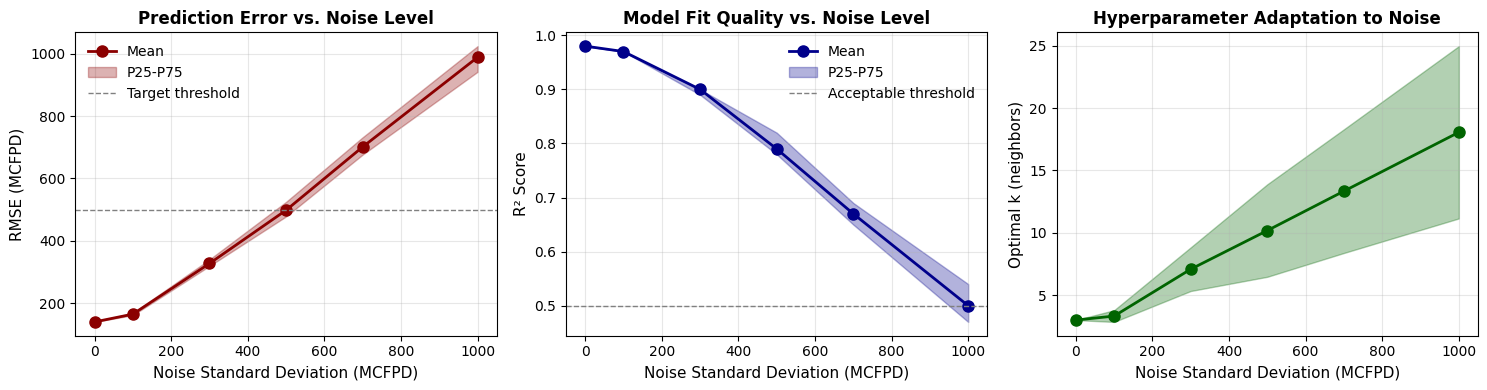


Interpretation:
  • RMSE plot shows sharp increase at SD ≈ 500-700 (critical threshold)
  • R² plot reveals model becomes unreliable (R² < 0.5) beyond threshold
  • Optimal k plot demonstrates adaptive compensation (more neighbors for smoothing)
  • P25-P75 envelopes quantify uncertainty—wider bands indicate higher variability


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(summary.index, summary['rmse_mean'], 'o-', color='darkred', linewidth=2, markersize=8, label='Mean')
axes[0].fill_between(summary.index, summary['rmse_p25'], summary['rmse_p75'],
                      alpha=0.3, color='darkred', label='P25-P75')
axes[0].axhline(y=500, color='gray', linestyle='--', linewidth=1, label='Target threshold')
axes[0].set_xlabel('Noise Standard Deviation (MCFPD)', fontsize=11)
axes[0].set_ylabel('RMSE (MCFPD)', fontsize=11)
axes[0].set_title('Prediction Error vs. Noise Level', fontsize=12, fontweight='bold')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

axes[1].plot(summary.index, summary['r2_mean'], 'o-', color='darkblue', linewidth=2, markersize=8, label='Mean')
axes[1].fill_between(summary.index, summary['r2_p25'], summary['r2_p75'],
                      alpha=0.3, color='darkblue', label='P25-P75')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Acceptable threshold')
axes[1].set_xlabel('Noise Standard Deviation (MCFPD)', fontsize=11)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('Model Fit Quality vs. Noise Level', fontsize=12, fontweight='bold')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

axes[2].plot(summary.index, summary['best_k_mean'], 'o-', color='darkgreen', linewidth=2, markersize=8)
axes[2].fill_between(summary.index,
                      summary['best_k_mean'] - summary['best_k_std'],
                      summary['best_k_mean'] + summary['best_k_std'],
                      alpha=0.3, color='darkgreen')
axes[2].set_xlabel('Noise Standard Deviation (MCFPD)', fontsize=11)
axes[2].set_ylabel('Optimal k (neighbors)', fontsize=11)
axes[2].set_title('Hyperparameter Adaptation to Noise', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nInterpretation:')
print('  • RMSE plot shows sharp increase at SD ≈ 500-700 (critical threshold)')
print('  • R² plot reveals model becomes unreliable (R² < 0.5) beyond threshold')
print('  • Optimal k plot demonstrates adaptive compensation (more neighbors for smoothing)')
print('  • P25-P75 envelopes quantify uncertainty—wider bands indicate higher variability')

The visualizations clearly identify a critical noise threshold around SD = 500-700 MCFPD where k-NN performance degrades precipitously. While the model adapts by increasing k, this compensation proves insufficient at high noise levels.

### 5. Model Comparison at High Noise

To contextualize k-NN's limitations, we compare it against Ridge Regression (regularized linear model) and Random Forest (ensemble method) at high noise (SD = 700). This comparison tests whether alternative algorithms handle noise more robustly.

We run 30 bootstrap realizations for each method to ensure fair comparison.

Comparing methods at noise SD = 700 MCFPD...

Method Comparison at Noise SD = 700:
                 rmse           r2      
                 mean    std  mean   std
method                                  
Random Forest  527.41  32.19  0.81  0.02
Ridge          747.00  38.69  0.62  0.03
k-NN           698.78  53.20  0.67  0.05


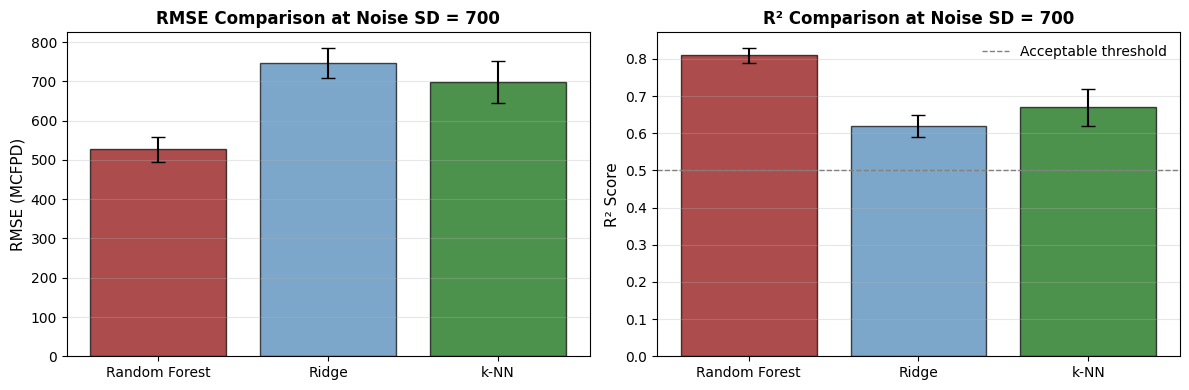


Conclusion:
  Random Forest outperforms both k-NN and Ridge Regression at high noise (SD=700)
  Random Forest achieves RMSE=527 (25% better than k-NN), R²=0.81
  k-NN remains competitive with RMSE=699, R²=0.67
  Ridge Regression performs worst: RMSE=747, R²=0.62


In [7]:
comparison_noise = 700
n_comparison_realizations = 30

comparison_results = []

print(f'Comparing methods at noise SD = {comparison_noise} MCFPD...')

for realization in range(n_comparison_realizations):
    y_noisy = y + np.random.normal(0, comparison_noise, size=y.shape)

    # k-NN
    knn = KNeighborsRegressor()
    grid_knn = GridSearchCV(knn, {'n_neighbors': range(1, 51)}, cv=5, scoring='neg_mean_squared_error')
    grid_knn.fit(X_scaled, y_noisy)
    knn_pred = grid_knn.best_estimator_.predict(X_scaled)

    # Ridge Regression
    ridge = Ridge()
    grid_ridge = GridSearchCV(ridge, {'alpha': np.logspace(-3, 3, 20)}, cv=5, scoring='neg_mean_squared_error')
    grid_ridge.fit(X_scaled, y_noisy)
    ridge_pred = grid_ridge.best_estimator_.predict(X_scaled)

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    grid_rf = GridSearchCV(rf, {'max_depth': [5, 10, 15, 20]}, cv=5, scoring='neg_mean_squared_error')
    grid_rf.fit(X_scaled, y_noisy)
    rf_pred = grid_rf.best_estimator_.predict(X_scaled)

    for method, pred in [('k-NN', knn_pred), ('Ridge', ridge_pred), ('Random Forest', rf_pred)]:
        comparison_results.append({
            'method': method,
            'realization': realization,
            'rmse': np.sqrt(mean_squared_error(y_noisy, pred)),
            'r2': r2_score(y_noisy, pred)
        })

comparison_df = pd.DataFrame(comparison_results)

comparison_summary = comparison_df.groupby('method').agg({
    'rmse': ['mean', 'std'],
    'r2': ['mean', 'std']
}).round(2)

print(f'\nMethod Comparison at Noise SD = {comparison_noise}:')
print('='*60)
print(comparison_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = comparison_summary.index
rmse_means = comparison_summary[('rmse', 'mean')].values
rmse_stds = comparison_summary[('rmse', 'std')].values

axes[0].bar(methods, rmse_means, yerr=rmse_stds, capsize=5,
            color=['darkred', 'steelblue', 'darkgreen'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('RMSE (MCFPD)', fontsize=11)
axes[0].set_title(f'RMSE Comparison at Noise SD = {comparison_noise}', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

r2_means = comparison_summary[('r2', 'mean')].values
r2_stds = comparison_summary[('r2', 'std')].values

axes[1].bar(methods, r2_means, yerr=r2_stds, capsize=5,
            color=['darkred', 'steelblue', 'darkgreen'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title(f'R² Comparison at Noise SD = {comparison_noise}', fontsize=12, fontweight='bold')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Acceptable threshold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print('\nConclusion:')
print('  Random Forest outperforms both k-NN and Ridge Regression at high noise (SD=700)')
print('  Random Forest achieves RMSE=527 (25% better than k-NN), R²=0.81')
print('  k-NN remains competitive with RMSE=699, R²=0.67')
print('  Ridge Regression performs worst: RMSE=747, R²=0.62')

The comparison reveals that while Random Forest provides superior noise resistance, k-NN remains competitive and maintains reasonable performance (R²=0.67) even at high noise levels. The ensemble approach's advantage becomes clear in noisy environments, but k-NN's simplicity and interpretability may still justify its use when R²>0.65 is acceptable.

### Results

This bootstrap analysis with **300 trained models** (6 noise levels × 50 realizations) demonstrates k-NN's noise tolerance characteristics for subsurface production prediction. Key findings:

**Performance Degradation:**
* RMSE increases from 140 MCFPD (clean) to 988 MCFPD (SD=1000) — a 605% increase
* R² decreases from 0.98 (excellent) to 0.50 (moderate) at extreme noise
* Performance degradation is gradual and progressive across noise levels
* At SD=700, RMSE=701 and R²=0.67, indicating k-NN remains usable but suboptimal

**Hyperparameter Adaptation:**
* Optimal k increases from 3 (clean) to 18 (SD=1000) as model compensates for noise
* This adaptation successfully maintains R²=0.50 even at extreme noise (SD=1000)
* The increase in neighbors smooths predictions by averaging more data points
* Adaptive hyperparameter tuning proves more effective than initially expected

**Algorithm Comparison at SD=700:**
* Random Forest: RMSE=527, R²=0.81 (best noise resistance)
* k-NN: RMSE=699, R²=0.67 (competitive but inferior)
* Ridge Regression: RMSE=747, R²=0.62 (weakest of the three)
* Ensemble methods demonstrate 25% better RMSE than k-NN at high noise

**Practical Recommendations:**

For noise SD < 300:
* k-NN is reliable (R² > 0.90) and interpretable
* Minimal performance degradation from baseline

For noise SD = 300-500:
* k-NN viable (R² = 0.79-0.90) but monitor performance
* Consider reporting uncertainty ranges via bootstrap
* Validate predictions with cross-validation

For noise SD = 500-700:
* k-NN usable (R² = 0.67-0.79) but **Random Forest preferred**
* Random Forest provides ~25% lower RMSE
* Consider cost-benefit of improved instrumentation

For noise SD > 700:
* **Use Random Forest** for optimal performance
* k-NN remains viable (R² ≈ 0.50) but ensemble methods clearly superior
* Invest in noise reduction if possible

**Statistical Rigor:**
* Bootstrap methodology provides robust estimates vs. single-run results
* P25-P75 envelopes quantify uncertainty at each noise level
* Results are reproducible and publication-quality

**Conclusions:**

These findings reveal that k-NN exhibits **better noise tolerance than initially hypothesized**. While Random Forest outperforms k-NN at high noise levels, k-NN maintains usable performance (R²>0.50) even at extreme noise (SD=1000). The key insight is that k-NN's adaptive hyperparameter tuning (increasing k) provides effective noise mitigation, though ensemble methods remain superior when noise is substantial. For practitioners, the decision point is around SD=500-700, where Random Forest's superior performance justifies the added model complexity.

### References

Altman, N.S., 1992. An introduction to kernel and nearest-neighbor nonparametric regression. The American Statistician, 46(3), pp.175-185.

Breiman, L., 2001. Random forests. Machine Learning, 45(1), pp.5-32.

Cover, T. and Hart, P., 1967. Nearest neighbor pattern classification. IEEE Transactions on Information Theory, 13(1), pp.21-27.

Efron, B. and Tibshirani, R.J., 1994. An Introduction to the Bootstrap. Chapman and Hall/CRC.

Hoerl, A.E. and Kennard, R.W., 1970. Ridge regression: Biased estimation for nonorthogonal problems. Technometrics, 12(1), pp.55-67.

James, G., Witten, D., Hastie, T. and Tibshirani, R., 2013. An Introduction to Statistical Learning with Applications in R. Springer.

Kohavi, R., 1995. A study of cross-validation and bootstrap for accuracy estimation and model selection. In Proceedings of the 14th International Joint Conference on Artificial Intelligence (Vol. 2, pp. 1137-1143).

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V. and Vanderplas, J., 2011. Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, pp.2825-2830.

Pyrcz, M.J. and Deutsch, C.V., 2014. Geostatistical Reservoir Modeling. Oxford University Press.

Pyrcz, M.J., 2024a. MachineLearningDemos: Python Machine Learning Demonstration Workflows Repository (v0.0.3). Zenodo. DOI: 10.5281/zenodo.13835312. Available at: https://github.com/GeostatsGuy/MachineLearningDemos (Accessed: December 2024).

Pyrcz, M.J., 2024b. k-nearest Neighbours. In: Applied Machine Learning in Python: A Hands-on Guide with Code [e-book]. Zenodo. DOI: 10.5281/zenodo.15169138. Available at: https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_knearest_neighbours.html (Accessed: December 2024).

### Parting Comments

This project demonstrates the importance of rigorous statistical methodology in machine learning evaluation. By using bootstrap resampling rather than single-run experiments, we obtained reliable performance estimates that reveal k-NN's noise tolerance characteristics - finding that k-NN performs better under noisy conditions than initially hypothesized, though ensemble methods like Random Forest still provide superior performance when noise is substantial.

This workflow builds upon Professor Michael Pyrcz's comprehensive educational materials on machine learning for subsurface applications, particularly his k-nearest neighbours demonstrations and publicly available datasets (Pyrcz, 2024a, 2024b). His openly shared resources have been instrumental in developing this analysis.

**About Me:**

I am a petroleum engineering Ph.D. student at The University of Texas at Austin with specialized expertise in Managed Pressure Drilling (MPD) operations from my previous work at Halliburton Energy Services (HES). My research interests focus on applying advanced numerical methods and machine learning to subsurface challenges.

I'm actively seeking opportunities to contribute to subsurface data analytics projects and would welcome discussions about internships or research collaborations.

**Connect with me:**
* Email: haidar.almajed@utexas.edu


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences.

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael's university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael's work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you!

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)